# Brazilian E-Commerce Market Analysis for Turkish e-commerce platform

**Student:** Selin Hacıoğlu - GH1045279  
**Programme:** MSc Data Science, AI and Digital Business  
**Module:** M504 AI and Applications  
**University:** GISMA University of Applied Sciences  
**Date:** May 2026  
**Dataset URL:** https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce

# 1. Introduction

E-commerce, which means the process of buying and selling products and services over the internet, has become one of the key points of the global market. Latin America has emerged as one of the fastest-growing digital markets (McKinsey & Company, 2025; EMARKETER, 2025). Brazil, which accounts for approximately 40% of the regional e-commerce market, presents an attractive opportunity for international growth (Market Data Forecast, 2026). However, entering a new market requires an understanding of local consumer behavior, operational challenges, and competitive dynamics (Laudon & Traver, 2023; Deloitte, 2024).

This analysis examines the Brazilian e-commerce environment from the angle of a Turkish e-commerce platform planning to enter the Latin American market. The dataset includes actual e-commerce data obtained from one of Brazil's largest marketplaces, Olist, which includes more than 100,000 orders. This exhaustive data set covers all 27 states of Brazil and addresses parameters such as customer feature, product categories, payment behaviors, delivery performance, and customer satisfaction.

The Brazilian market was selected for its behavioral similarities with Turkey like culture of installment payments and mobile-first shopping habits (dLocal, 2023; J.P. Morgan, n.d.). In addition to this Brazilian market also sellected its role as a door to the large and growing middle class and the broader Latin American region . The data set covering the 2016–2018 period but it reflects key market dynamics such as customer locations, payment behaviors, and logistics models that display structural stability over time (Baldauf, 2024; Krumme et al., 2013). This pre-pandemic reference provides us with a basis for identifying long-term trends rather than specific anomalies related to the COVID era. Potential limitations related to the time frame are addressed in the discussion section of the study’s conclusions.

The analysis begins with an initial phase covering customer segmentation, product choices, and payment behaviors; then continues with delivery performance, shipping costs, and customer satisfaction. The final stage addresses growth strategy specifically, geographical priorities, suppliers, and seasonal planning. Questions regarding these topics have been identified, and the focus has been placed on the answers to these questions.

**Phase 1 – Understand the Market: Customers, Products & Payments**

1. In which states are customers and revenue concentrated within Brazilian e-commerce?
2. Which product categories generate the most revenue and demand?
3. What are the dominant payment methods, and how prevalent is installment usage?

**Phase 2 – Operational Excellence**

4. How does delivery performance vary across regions and how does it impact customer satisfaction?
5. What are the freight cost dynamics and is a free shipping strategy feasible?
6. What factors drive customer review scores and where are the quality issues?

**Phase 3 – Growth Strategy**

7. Which states and cities should be prioritized for geographic expansion?
8. What characteristics define top-performing sellers and how should the marketplace grow?
9. What seasonal demand patterns exist and when is the optimal time to launch?

# 2. Business Context

## 2.1 Client Perspective 
This case study was designed for Trendyol, which is a Turkish e-commerce platform that serves as Turkey’s largest e-commerce marketplace, connecting thousands of sellers with millions of buyers. Building on its strong domestic presence, the company identified Latin America as its next strategic growth market and selected Brazil as its primary entry point.

## 2.2 Business Problem
Brazil shares many behavioral similarities with Turkey, but the company still needs data-driven answers to critical strategic questions before investing in the market: In which regions are Brazilian e-commerce customers primarily located? What do they buy, and how do they pay? What are the logistical challenges? Where should initial operations be focused?

## 2.3 Dataset

The analysis focused on the Olist Brazilian E-Commerce Public Dataset, which has real commercial data collecting from one of Brazil's largest marketplace platforms(Olist). The dataset consists of 9 interconnected tables covering customers, orders, products, payments, reviews, sellers, geolocation, and category translations.

**References** [Kaggle - Olist Dataset](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce)

# 3. Data Exploration
## 3.1 Setup and Data Loading

The libraries used in this analysis are as follows: `pandas` for data manipulation, `numpy` for numerical operations, `matplotlib` and `seaborn` for visualization, and `datetime` for time series analysis.

In [262]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')
from matplotlib.ticker import FuncFormatter
import squarify


plt.rcParams['text.color'] = '#333333'
plt.rcParams['axes.labelcolor'] = '#333333'
plt.rcParams['xtick.color'] = '#333333'
plt.rcParams['ytick.color'] = '#333333'


customers = pd.read_csv('olist_customers_dataset.csv')
orders = pd.read_csv('olist_orders_dataset.csv')
order_items = pd.read_csv('olist_order_items_dataset.csv')
products = pd.read_csv('olist_products_dataset.csv')
sellers = pd.read_csv('olist_sellers_dataset.csv')
payments = pd.read_csv('olist_order_payments_dataset.csv')
reviews = pd.read_csv('olist_order_reviews_dataset.csv')
geolocation = pd.read_csv('olist_geolocation_dataset.csv')
category_translation = pd.read_csv('product_category_name_translation.csv')

## 3.2 Dataset Overview

The table created below summarizes the size, completeness, and quality of each dataset. This first look helps identify which tables need closer attention during the data preparation phase.

In [263]:

datasets = {
    'customers': customers,
    'orders': orders,
    'order_items': order_items,
    'products': products,
    'sellers': sellers,
    'payments': payments,
    'reviews': reviews,
    'geolocation': geolocation,
    'category_translation': category_translation
}

overview = pd.DataFrame({
    'Rows': [df.shape[0] for df in datasets.values()],
    'Columns': [df.shape[1] for df in datasets.values()],
    'Missing Values': [df.isnull().sum().sum() for df in datasets.values()],
    'Duplicates': [df.duplicated().sum() for df in datasets.values()]
}, index=datasets.keys())

print("Dataset Overview:")
print(overview)

Dataset Overview:
                         Rows  Columns  Missing Values  Duplicates
customers               99441        5               0           0
orders                  99441        8            4908           0
order_items            112650        7               0           0
products                32951        9            2448           0
sellers                  3095        4               0           0
payments               103886        5               0           0
reviews                 99224        7          145903           0
geolocation           1000163        5               0      261831
category_translation       71        2               0           0


## 3.3 Data Quality Assessment
A closer look at the tables with missing values shows the following details:

Orders: Missing values are in the date columns related to delivery; but this is normal, since some orders have been canceled, shipped, or are currently being processed.

Products: 610 products (1.9%) lack a category name and metadata. This number is much lower than the 5% threshold, which is generally considered the point at which missing data may negatively affect analytical results (Srijan & Rajagopalan, 2024). Additionally, just 2 items have missing information about their physical dimensions.

Reviews: A significant portion of the reviews lack written comments (87,656 missing titles, 58,247 missing messages). This reflects typical user behavior, as many customers provide only a star rating without writing a text review. The numerical `review_score` column is fully complete and sufficient for our analysis.

These patterns align with realistic e-commerce data and do not show any signs of data corruption. Each issue is addressed in the following preprocessing step.

In [264]:
print("Missing Values - Orders Table:")
print(orders.isnull().sum())

print("\nMissing Values - Products Table:")
print(products.isnull().sum())

print("\nMissing Values - Reviews Table:")
print(reviews.isnull().sum())

Missing Values - Orders Table:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

Missing Values - Products Table:
product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

Missing Values - Reviews Table:
review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64


### 3.4 Key Data Observations

Prior to data preprocessing, several important characteristics were identified within the dataset. The dataset covers all 27 states of Brazil, giving us the opportunity to perform a nationwide analysis. The existence of 99,441 orders and 112,650 order items indicates that many orders contain multiple products and suggests the potential for crossover sales. With only 96,096 unique customers corresponding to 99,441 customer IDs, it is clear that approximately 3,345 customers are repeat buyers. On the product side, 32,951 products span 72 distinct categories. In the payments table, the existence of 103,886 records for 99,441 orders indicates that multiple payment methods were used for certain orders. Finally, the presence of 99,224 review records, which means that nearly every order has been rated and it shows a strong culture of customer feedback.

### 3.5 Data Preprocessing

The following preprocessing steps were applied to prepare the data for analysis:

**1- Date conversion:** All date columns in the order and review tables were converted from string format to datetime format for temporal analysis.

**2- Category translation:** Product category names were translated from Portuguese to English using the provided translation table.

**3- Missing categories:** 623 products without category names were labeled as “unknown” to be retained in the dataset without introducing bias.
**4- Missing dimensions:** Two products with missing weight and dimension values were imputed with median values to prevent data loss in shipping cost analysis.

**5- Missing delivery dates:** Orders without delivery dates represent undelivered orders (cancelled, in progress). These records are retained as NaT and filtered out in delivery-focused analyses.

**6- Missing review comments:** Approximately 59% of reviews lack written comments. Since the numerical rating is complete and sufficient for satisfaction analysis, no further action is required.

**7- Duplicate geographic locations:** Since there were multiple coordinate records for the same ZIP code prefix, 261,831 duplicate rows were removed from the geographic location table.


In [265]:

date_columns = ['order_purchase_timestamp', 'order_approved_at', 
                'order_delivered_carrier_date', 'order_delivered_customer_date', 
                'order_estimated_delivery_date']

for col in date_columns:
    orders[col] = pd.to_datetime(orders[col])

reviews['review_creation_date'] = pd.to_datetime(reviews['review_creation_date'])
reviews['review_answer_timestamp'] = pd.to_datetime(reviews['review_answer_timestamp'])


products = products.merge(category_translation, on='product_category_name', how='left')
products['product_category_name_english'] = products['product_category_name_english'].fillna('unknown')


dimension_cols = ['product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']
for col in dimension_cols:
    products[col] = products[col].fillna(products[col].median())


geo_before = len(geolocation)
geolocation = geolocation.drop_duplicates()
geo_after = len(geolocation)


print("Preprocessing completed successfully.\n")
print(f"Date range: {orders['order_purchase_timestamp'].min().date()} to {orders['order_purchase_timestamp'].max().date()}")
print(f"Product categories: {products['product_category_name_english'].nunique()} unique")
print(f"Unknown categories: {(products['product_category_name_english'] == 'unknown').sum()}")
print(f"Missing dimensions: {products[dimension_cols].isnull().sum().sum()}")
print(f"Geolocation: {geo_before:,} → {geo_after:,} rows ({geo_before - geo_after:,} duplicates removed)")
print(f"\nOrder status distribution:")
print(orders['order_status'].value_counts())

Preprocessing completed successfully.

Date range: 2016-09-04 to 2018-10-17
Product categories: 72 unique
Unknown categories: 623
Missing dimensions: 0
Geolocation: 1,000,163 → 738,332 rows (261,831 duplicates removed)

Order status distribution:
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


### 3.6 Data Preparation for Analysis

After completing the preprocessing steps, the tables were consolidated and basic calculations were performed for use in the analysis phase. In this step, the order, customer, product, and order line tables were consolidated into a single master table; customer and revenue analysis at the state level was prepared; and a customer loyalty classification was created.

In [266]:
customer_orders = orders.merge(customers, on='customer_id') \
                        .merge(order_items, on='order_id') \
                        .merge(products, on='product_id')

state_analysis = customer_orders.groupby('customer_state').agg(
    customer_count=('customer_unique_id', 'nunique'),
    total_revenue=('price', 'sum')
).sort_values('total_revenue', ascending=False)

customer_orders_count = customer_orders.groupby('customer_unique_id').agg(
    order_count=('order_id', 'nunique'),
    total_spent=('price', 'sum')
).reset_index()

customer_orders_count['customer_type'] = customer_orders_count['order_count'].apply(
    lambda x: 'Repeat' if x > 1 else 'One-Time'
)

customer_with_type = customer_orders.merge(
    customer_orders_count[['customer_unique_id', 'customer_type']], 
    on='customer_unique_id'
)

print(f"Master table: {len(customer_orders):,} rows")
print(f"Unique customers: {customer_orders['customer_unique_id'].nunique():,}")
print(f"One-Time: {(customer_orders_count['customer_type']=='One-Time').sum():,}")
print(f"Repeat: {(customer_orders_count['customer_type']=='Repeat').sum():,}")

Master table: 112,650 rows
Unique customers: 95,420
One-Time: 92,507
Repeat: 2,913


## 4. Exploratory Data Analysis

### Phase 1: Understanding the Market: Customers, Products, and Payments

Before entering a new market, it is essential to understand who the customers are, what they purchase, and how they make payments. This phase serves as the foundation for subsequent strategic decisions.

### 4.1 Question 1: In which states are customers and revenue concentrated within Brazilian e-commerce?

**Business Significance:** Understanding the geographic distribution and loyalty behaviors of existing customers directly shapes decisions regarding launch locations, marketing budget allocation, and priority customer segments. A market where demand is concentrated in a few specific regions requires a different entry strategy compared to a market with an even distribution.

This analysis examines customers from two perspectives: (1) geographic concentration at the state and city levels; and (2) the loyalty behaviors and geographic distribution of one-time buyers versus repeat customers.

#### 4.1.1 Geographic Distribution: State and City Levels

As a first step, it is crucial to understand in which geographic regions customers and revenue are concentrated. The three graphs below show the distribution of customer numbers and revenue at the state level, followed by a ranking of revenue at the city level. By proceeding from the general to the specific, it becomes clear exactly which areas efforts should be focused on.

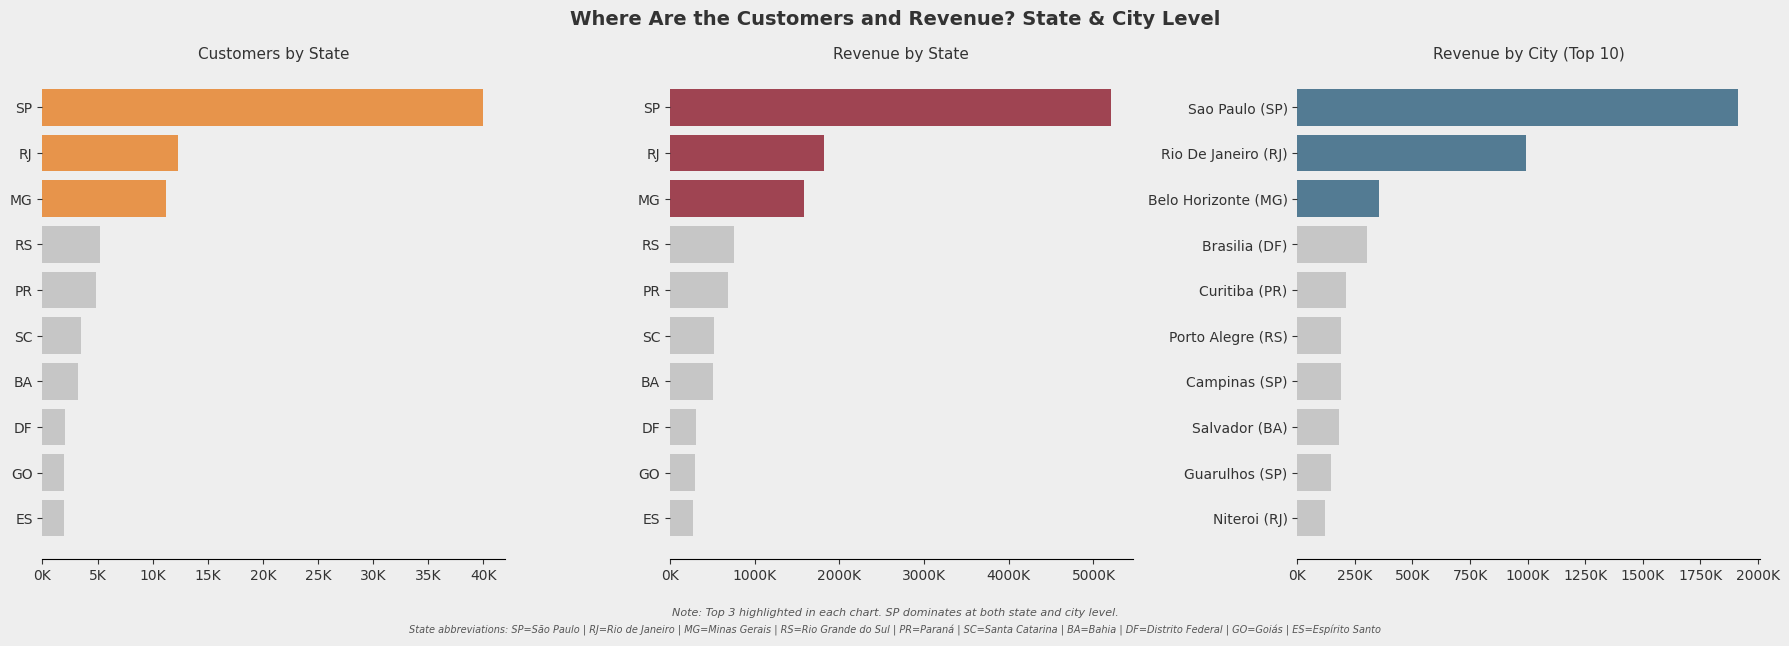

In [267]:
top10 = state_analysis.head(10)

city_revenue = customer_orders.groupby(['customer_city', 'customer_state'])['price'].sum()
city_revenue = city_revenue.sort_values(ascending=False).head(10)
city_labels = [f"{city.title()} ({state})" for city, state in city_revenue.index]

customer_colors = ['#E67E22']*3 + ['#BDBDBD']*7
revenue_colors = ['#8B1A2B']*3 + ['#BDBDBD']*7
city_colors = ['#2C5F7C']*3 + ['#BDBDBD']*7

fig, (axConsumers, axrevenue, axrevenue_10) = plt.subplots(1, 3, figsize=(18, 6))
fig.patch.set_facecolor('#EEEEEE')
for ax in [axConsumers, axrevenue, axrevenue_10]:
    ax.set_facecolor('#EEEEEE')

axConsumers.barh(top10.index, top10['customer_count'], color=customer_colors, alpha=0.8)
axConsumers.set_title('Customers by State', fontsize=11)
axConsumers.invert_yaxis()

axrevenue.barh(top10.index, top10['total_revenue'], color=revenue_colors, alpha=0.8)
axrevenue.xaxis.set_major_formatter(FuncFormatter(lambda x, p: f'{x/1e6:.1f}M'))
axrevenue.set_title('Revenue by State', fontsize=11)
axrevenue.invert_yaxis()

axrevenue_10.barh(city_labels, city_revenue.values, color=city_colors, alpha=0.8)
axrevenue_10.xaxis.set_major_formatter(FuncFormatter(lambda x, p: f'{x/1e6:.1f}M'))
axrevenue_10.set_title('Revenue by City (Top 10)', fontsize=11)
axrevenue_10.invert_yaxis()

axConsumers.xaxis.set_major_formatter(FuncFormatter(lambda x, p: f'{x/1000:.0f}K'))
axrevenue.xaxis.set_major_formatter(FuncFormatter(lambda x, p: f'{x/1000:.0f}K'))
axrevenue_10.xaxis.set_major_formatter(FuncFormatter(lambda x, p: f'{x/1000:.0f}K'))

for ax in [axConsumers, axrevenue, axrevenue_10]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)

fig.suptitle('Where Are the Customers and Revenue? State & City Level', 
             fontsize=14, fontweight='bold', y=0.98)

fig.text(0.5, -0.03, 
         'Note: Top 3 highlighted in each chart. SP dominates at both state and city level.',
         ha='center', fontsize=8, fontstyle='italic', color='#555555')
fig.text(0.5, -0.06, 
         'State abbreviations: SP=São Paulo | RJ=Rio de Janeiro | MG=Minas Gerais | RS=Rio Grande do Sul | PR=Paraná | SC=Santa Catarina | BA=Bahia | DF=Distrito Federal | GO=Goiás | ES=Espírito Santo',
         ha='center', fontsize=7, fontstyle='italic', color='#555555')

plt.tight_layout()
plt.show()

The Brazilian e-commerce market is highly concentrated in the Southeast region. São Paulo (SP) dominates both customer count and revenue by a wide margin, followed by Rio de Janeiro (RJ) and Minas Gerais (MG). The top 5 states alone account for the vast majority of total revenue, confirming that the client should focus initial operations on the Southeast corridor rather than attempting nationwide coverage.The Brazilian e-commerce market is heavily focused in the Southeast region. São Paulo (SP) clearly outpaces other states in both the number of customers and revenue.  Rio de Janeiro (RJ) and Minas Gerais (MG) are close behind. When we look at the revenue distribution at the city level, the same pattern stands out. The city of São Paulo alone tops the list with approximately R$ 2 million in revenue. A notable finding is that while Brasília (DF) ranks 8th among states, it ranks in the top 5 at the city level; this indicates that the capital has high purchasing power. These results suggest that the client company should focus its initial operations on the Southeast corridor rather than expanding nationwide.

#### 4.1.2 Customer Loyalty: One-Time and Repeat Buyers

While knowing customers’ geographic locations is important, understanding their loyalty behaviors is equally critical. It is well known in the literature that attracting new customers is significantly more costly than keeping existing ones. This analysis compares one-time buyers with repeat customers in terms of number, average spending, and geographic distribution.

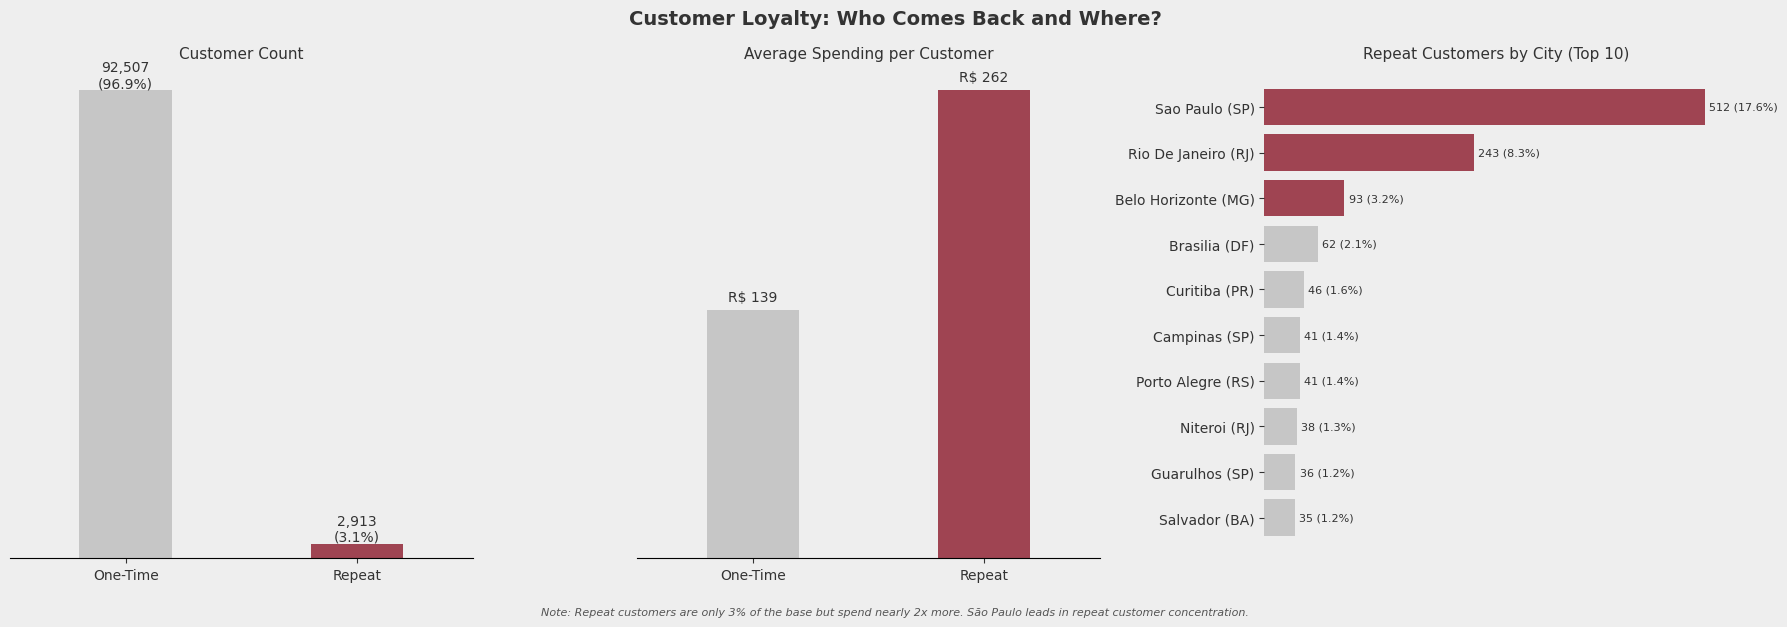

In [268]:

repeat_by_city = customer_with_type[
    customer_with_type['customer_type'] == 'Repeat'
].groupby(['customer_city', 'customer_state'])['customer_unique_id'].nunique()
repeat_by_city = repeat_by_city.sort_values(ascending=False).head(10)
total_repeat = customer_with_type[customer_with_type['customer_type'] == 'Repeat']['customer_unique_id'].nunique()
city_labels = [f"{city.title()} ({state})" for city, state in repeat_by_city.index]


type_summary = customer_orders_count.groupby('customer_type').agg(
    customers=('customer_unique_id', 'count'),
    avg_spent=('total_spent', 'mean')
)
total_customers = type_summary['customers'].sum()

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))
fig.patch.set_facecolor('#EEEEEE')
for ax in [ax1, ax2, ax3]:
    ax.set_facecolor('#EEEEEE')

colors = ['#BDBDBD', '#8B1A2B']


barscustomer = ax1.bar(type_summary.index, type_summary['customers'], color=colors, width=0.4, alpha=0.8)
ax1.set_title('Customer Count', fontsize=11)
for bar, val in zip(barscustomer, type_summary['customers']):
    pct = val / total_customers * 100
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500, 
             f'{val:,}\n({pct:.1f}%)', ha='center', fontsize=10)


barsSpending = ax2.bar(type_summary.index, type_summary['avg_spent'], color=colors, width=0.4, alpha=0.8)
ax2.set_title('Average Spending per Customer', fontsize=11)
for bar, val in zip(barsSpending, type_summary['avg_spent']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, 
             f'R$ {val:,.0f}', ha='center', fontsize=10)


city_colors = ['#8B1A2B']*3 + ['#BDBDBD']*7
ax3.barh(city_labels, repeat_by_city.values, color=city_colors, alpha=0.8)
ax3.invert_yaxis()
ax3.set_title('Repeat Customers by City (Top 10)', fontsize=11)
for i, val in enumerate(repeat_by_city.values):
    pct = val / total_repeat * 100
    ax3.text(val + 5, i, f'{val} ({pct:.1f}%)', va='center', fontsize=8)

for ax in [ax1, ax2]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.set_yticks([])
    ax.set_xlim(-0.5, 1.5)

ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.spines['bottom'].set_visible(False)
ax3.spines['left'].set_visible(False)
ax3.set_xticks([])

fig.suptitle('Customer Loyalty: Who Comes Back and Where?', 
             fontsize=14, fontweight='bold', y=0.98)

fig.text(0.5, -0.03, 
         'Note: Repeat customers are only 3% of the base but spend nearly 2x more. São Paulo leads in repeat customer concentration.',
         ha='center', fontsize=8, fontstyle='italic', color='#555555')

plt.tight_layout()
plt.show()

The results show a remarkable pattern. Most customers (92,507) are one-time buyers, while only 2,913 customers approximately 3% have made repeat purchases. However, repeat customers spend nearly twice as much on an average purchase. In terms of geographic distribution, repeat customers are again concentrated in São Paulo, Rio de Janeiro, and Belo Horizonte, confirming the general market concentration shown in the first figure.

These findings offer important strategic insights. While customer acquisitions are essential during the market entry phase, creating a loyalty plan in the early stages can significantly increase customer lifetime value. The low repeat purchase rate also represents an opportunity; even a small improvement in the repeat purchase rate would have a significant impact on revenue.

### 4.2 Question 2: Which product categories generate the most revenue and demand?

**Business Significance:** Once you understand the customer profile and geographic distribution, the next question to answer is what these customers are buying. Knowing which categories generate the most revenue and which have the highest sales volume directly shapes decisions about initial inventory, supplier partnerships, and marketing strategy.

This analysis examines product categories from two perspectives: (1) revenue distribution and (2) the combined evaluation of order volume and average price.

#### 4.2.1 Revenue Distribution by Category

The treemap below visualizes the distribution of total revenue across product categories. Larger boxes represent a higher share of revenue.


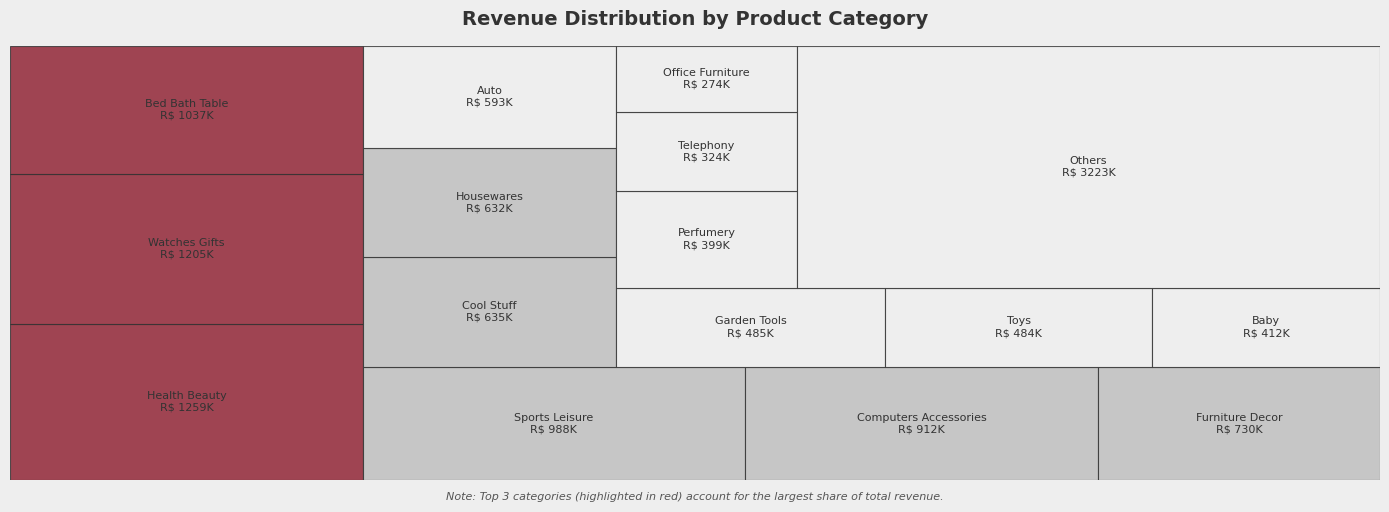

In [269]:

category_analysis = customer_orders.groupby('product_category_name_english').agg(
    order_count=('order_id', 'nunique'),
    total_revenue=('price', 'sum'),
    avg_price=('price', 'mean')
).sort_values('total_revenue', ascending=False)

top15 = category_analysis.head(15)
others_revenue = category_analysis.iloc[15:]['total_revenue'].sum()

treemap_data = pd.concat([top15['total_revenue'], 
                          pd.Series({'others': others_revenue})])

labels = [f"{name.replace('_', ' ').title()}\nR$ {val/1000:.0f}K" for name, val in treemap_data.items()]
colors = ['#8B1A2B']*3 + ['#BDBDBD']*5 + ['#EEEEEE']*8

fig, ax = plt.subplots(figsize=(14, 5))
fig.patch.set_facecolor('#EEEEEE')
ax.set_facecolor('#EEEEEE')

squarify.plot(sizes=treemap_data.values, label=labels, color=colors, 
              alpha=0.8, text_kwargs={'fontsize': 8}, ax=ax,
              edgecolor='#333333', linewidth=0.8)

ax.set_title('Revenue Distribution by Product Category', 
             fontsize=14, fontweight='bold', pad=15)
ax.axis('off')

fig.text(0.5, -0.01, 
         'Note: Top 3 categories (highlighted in red) account for the largest share of total revenue.',
         ha='center', fontsize=8, fontstyle='italic', color='#555555')

plt.tight_layout()
plt.show()

The treemap shows that revenue is concentrated in specific categories. Health Beauty (R$ 1,259K), Watches Gifts (R$ 1,205K), and Bed Bath Table (R$ 1,037K) stand out as the top three revenue-generating categories. These top three categories alone represent a significant portion of total revenue, while the remaining categories have relatively smaller shares. This concentration suggests that focusing on a limited number of categories during the market entry phase is a rational strategy.

#### 4.2.2 Order Volume and Average Price by Category

While the treemap shows where revenue is concentrated, it does not reveal whether a category stands out because it has a high number of orders or because of its high price. The following dual-axis chart combines these two dimensions. The bars show the number of orders, while the orange line indicates the average price per category.


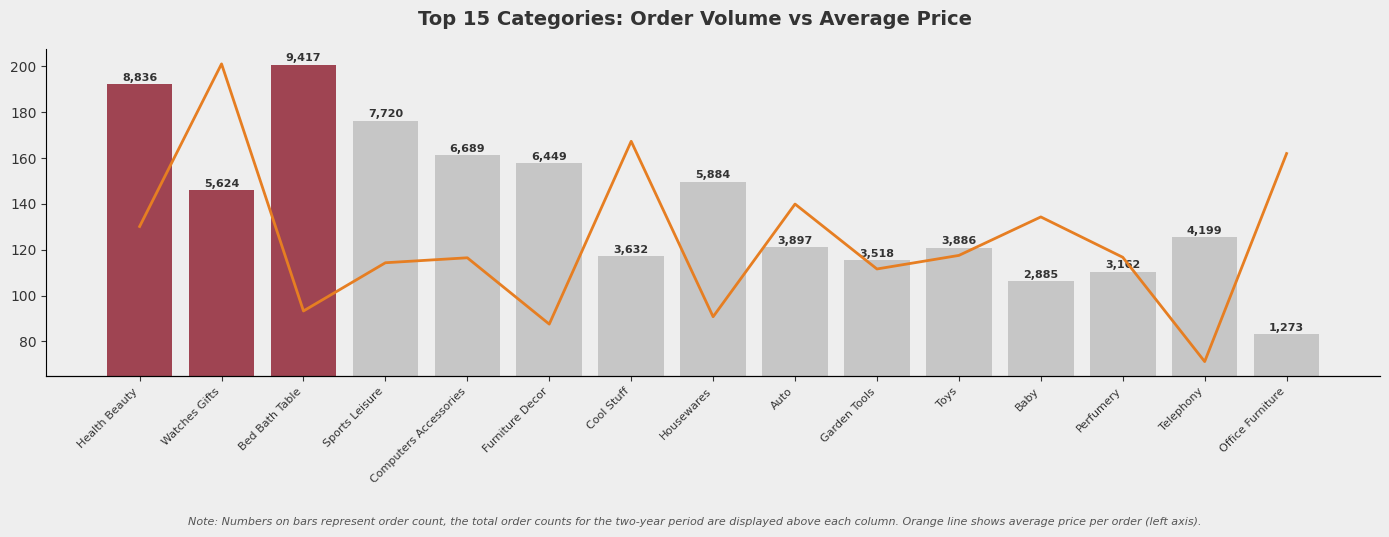

In [270]:

top15_dual = category_analysis.head(15)

fig, ax1 = plt.subplots(figsize=(14, 5))
fig.patch.set_facecolor('#EEEEEE')
ax1.set_facecolor('#EEEEEE')


bar_colors = ['#8B1A2B']*3 + ['#BDBDBD']*12
bars = ax1.bar(range(len(top15_dual)), top15_dual['order_count'], color=bar_colors, alpha=0.8)


for i, val in enumerate(top15_dual['order_count']):
    ax1.text(i, val + 100, f'{val:,}', ha='center', fontsize=8, fontweight='bold')


ax1.set_yticks([])
ax1.set_ylabel('')

ax1.set_xticks(range(len(top15_dual)))
ax1.set_xticklabels([name.replace('_', ' ').title() for name in top15_dual.index], 
                     rotation=45, ha='right', fontsize=8)


ax2 = ax1.twinx()
ax2.plot(range(len(top15_dual)), top15_dual['avg_price'], color='#E67E22', 
         linewidth=2)
ax2.yaxis.set_label_position('left')
ax2.yaxis.tick_left()


ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_visible(False)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

fig.suptitle('Top 15 Categories: Order Volume vs Average Price', 
             fontsize=14, fontweight='bold', y=0.98)

fig.text(0.5, -0.05, 
         'Note: Numbers on bars represent order count, the total order counts for the two-year period are displayed above each column. Orange line shows average price per order (left axis).',
         ha='center', fontsize=8, fontstyle='italic', color='#555555')

plt.tight_layout()
plt.show()

This chart reveals important details. Health Beauty and Bed Bath and Table lead in both order volume and revenue, confirming massive market demand. Watches and Gifts, despite having fewer orders, point to a premium segment due to their high average price. Categories like Cool Stuff and Office Furniture have low volume but the highest average prices. Housewares, on the other hand, represents a price-sensitive consumer base with high volume but low price points.

### 4.3 Question 3: 3. What are the dominant payment methods, and how are they used?

**Business Implications:** Payment preferences are one of the most critical components of a market entry strategy. In Brazil, the culture of installment payments is widespread, similar to that in Turkey. Understanding which payment methods are preferred and installment payment habits directly shapes decisions regarding payment infrastructure, financing partnerships, and pricing strategies.

This analysis examines payment behavior from two perspectives: (1) the overall distribution of payment methods and (2) the installment preferences of credit card users.

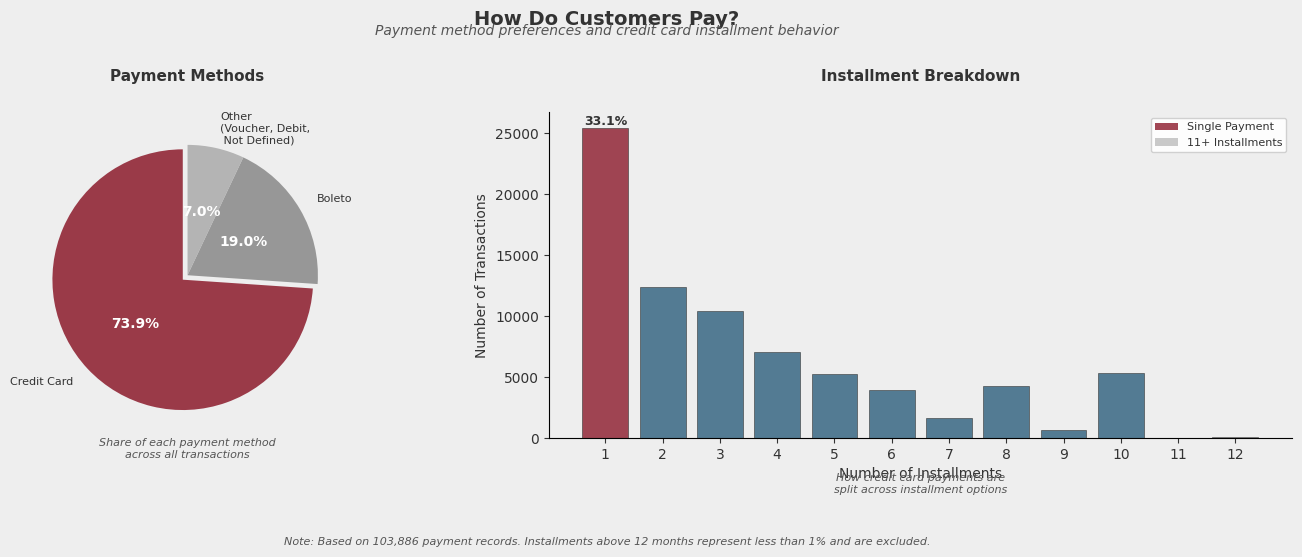

In [272]:
# Payment data - 3 slices
payment_dist = payments['payment_type'].value_counts()
main_payments = pd.Series({
    'Credit Card': payment_dist.get('credit_card', 0),
    'Boleto': payment_dist.get('boleto', 0),
    'Other': payment_dist.get('voucher', 0) + payment_dist.get('debit_card', 0) + payment_dist.get('not_defined', 0)
})

pie_colors = ['#8B1A2B', '#888888', '#AAAAAA']
explode = [0.05, 0, 0]

# Installment data
cc_payments = payments[(payments['payment_type'] == 'credit_card') & (payments['payment_installments'] > 0)]
installment_counts = cc_payments['payment_installments'].value_counts().sort_index()
installment_counts_trimmed = installment_counts[installment_counts.index <= 12]

# Figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={'width_ratios': [0.5, 0.7]})
fig.patch.set_facecolor('#EEEEEE')
ax1.set_facecolor('#EEEEEE')
ax2.set_facecolor('#EEEEEE')

fig.suptitle('How Do Customers Pay?', fontsize=14, fontweight='bold', y=1.02)
fig.text(0.5, 0.97, 'Payment method preferences and credit card installment behavior', 
         ha='center', fontsize=10, fontstyle='italic', color='#555555')

# Left: Pie chart
wedges, texts, autotexts = ax1.pie(
    main_payments.values,
    labels=['Credit Card', 'Boleto', 'Other\n(Voucher, Debit,\n Not Defined)'],
    autopct='%1.1f%%',
    colors=pie_colors,
    pctdistance=0.5,
    labeldistance=1.15,
    startangle=90,
    explode=explode,
    wedgeprops=dict(alpha=0.85)
)

for text in texts:
    text.set_fontsize(8)
for text in autotexts:
    text.set_fontsize(10)
    text.set_fontweight('bold')
    text.set_color('white')

ax1.set_title('Payment Methods\n', fontsize=11, fontweight='bold', pad=10)
ax1.text(0, -1.4, 'Share of each payment method\nacross all transactions', 
         ha='center', fontsize=8, fontstyle='italic', color='#555555')

# Right: Histogram
total_cc = len(cc_payments)
bar_colors = []
for x in installment_counts_trimmed.index:
    if x == 1:
        bar_colors.append('#8B1A2B')
    elif x <= 10:
        bar_colors.append('#2C5F7C')
    else:
        bar_colors.append('#BDBDBD')

ax2.bar(installment_counts_trimmed.index, installment_counts_trimmed.values, color=bar_colors, 
        alpha=0.8, edgecolor='#333333', linewidth=0.5)

for x, val in installment_counts_trimmed.items():
    if x == 1:
        ax2.text(x, val + 200, f'{val/total_cc*100:.1f}%', ha='center', fontsize=9, fontweight='bold')

ax2.set_xlabel('Number of Installments')
ax2.set_ylabel('Number of Transactions')
ax2.set_xticks(range(1, 13))
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.set_title('Installment Breakdown\n', fontsize=11, fontweight='bold', pad=10)
ax2.text(6.5, -4500, 'How credit card payments are\nsplit across installment options', 
         ha='center', fontsize=8, fontstyle='italic', color='#555555')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#8B1A2B', alpha=0.8, label='Single Payment'),
                   Patch(facecolor='#BDBDBD', alpha=0.8, label='11+ Installments')]
ax2.legend(handles=legend_elements, loc='upper right', fontsize=8, framealpha=0.9)

fig.text(0.5, -0.05,
         f'Note: Based on {len(payments):,} payment records. Installments above 12 months represent less than 1% and are excluded.',
         ha='center', fontsize=8, fontstyle='italic', color='#555555')

plt.tight_layout()
plt.subplots_adjust(wspace=0.15)
plt.show()

The results show that credit cards are by far the dominant payment method, accounting for 73.9% of the market. Boleto (a Brazil-specific bank payment slip) ranks second at 19%. Looking at the installment distribution, only 33.1% of credit card users make a single-payment transaction, while the remaining 66.9% prefer installment payments. While the most common installment range is 2–4, the 10-installment option is also observed to have significant usage. This confirms that Brazilian consumers view installment payments not as a preference but as an expectation.

These findings point to a significant advantage for the client company: Turkey’s experience with installment payment infrastructure is directly transferable to the Brazilian market. The platform must offer options for at least 10 installments, and installment agreements with local banks should be a priority component of the market entry strategy.

### Faz 2: Operasyonel Mükemmellik — Teslimat, Maliyet ve Memnuniyet

Pazar dinamiklerini anladıktan sonra sıra operasyonel zorluklara gelmektedir. E-ticarette başarı müşteri deneyimine, müşteri deneyimi ise teslimat ve lojistik performansına doğrudan bağlıdır. Bu faz, teslimat sürelerini, kargo maliyetlerini ve bunların müşteri memnuniyetine etkisini incelemektedir.

### 4.4 Soru 4: Teslimat Performansı Bölgelere Göre Nasıl Değişiyor ve Müşteri Memnuniyetini Nasıl Etkiliyor?

**İş Önemi:** Teslimat süresi, e-ticarette müşteri memnuniyetinin en belirleyici faktörüdür. Hangi bölgelerde teslimatın hızlı, hangilerinde yavaş olduğunu ve bu farklılıkların müşteri puanlamalarına nasıl yansıdığını anlamak; depo konumları, lojistik ortaklıkları ve hizmet seviyesi hedeflerini doğrudan şekillendirmektedir.

Bu analiz, teslimat performansını iki açıdan incelemektedir: (1) eyaletlere göre teslimat süresi dağılımı ve (2) teslimat gecikmesinin müşteri memnuniyet puanına etkisi.

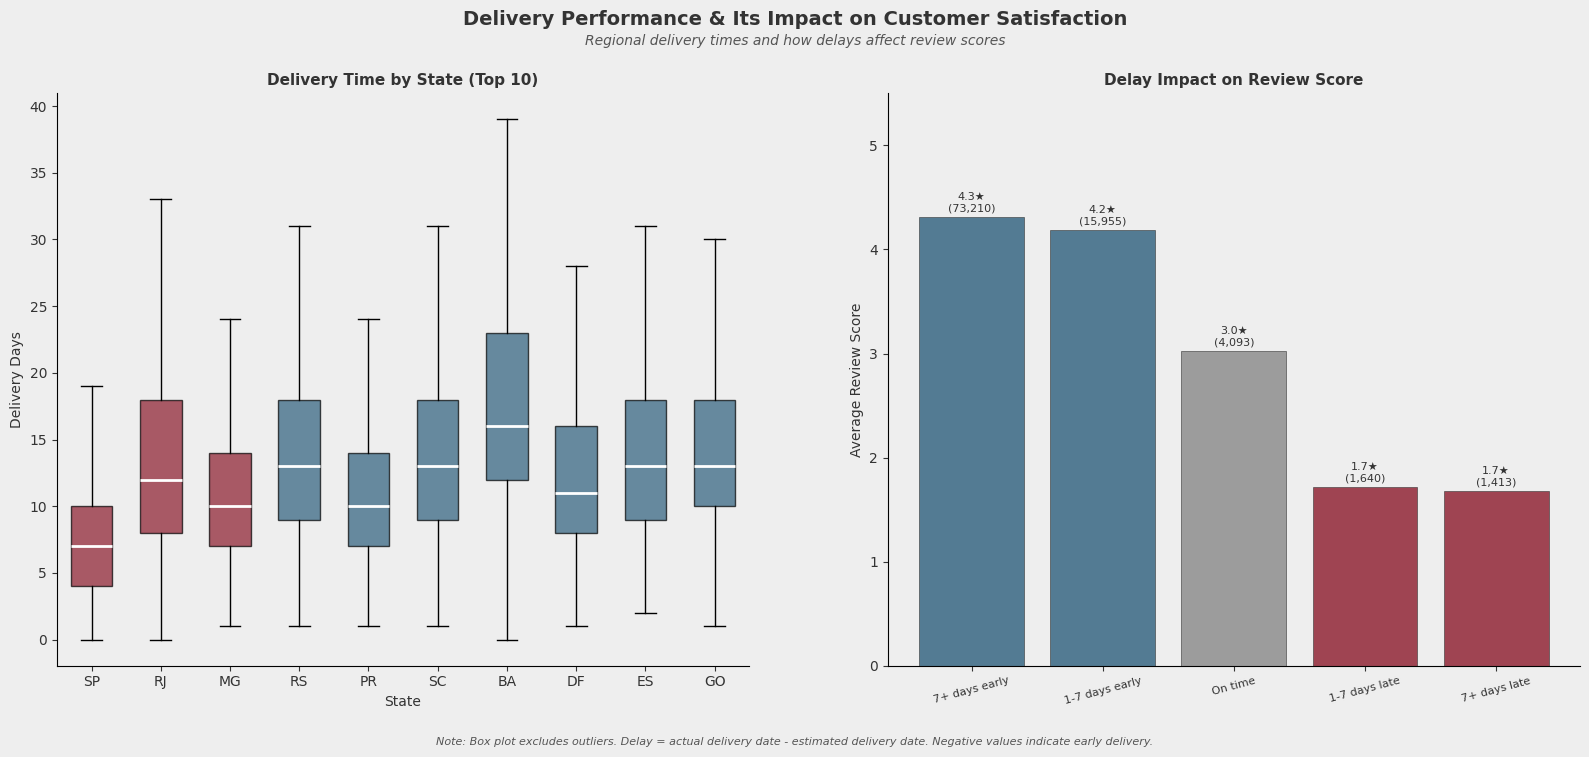

In [274]:
# Delivery time calculation
delivered_orders = orders[orders['order_status'] == 'delivered'].copy()
delivered_orders['delivery_days'] = (
    delivered_orders['order_delivered_customer_date'] - delivered_orders['order_purchase_timestamp']
).dt.days
delivered_orders['estimated_days'] = (
    delivered_orders['order_estimated_delivery_date'] - delivered_orders['order_purchase_timestamp']
).dt.days
delivered_orders['delay_days'] = delivered_orders['delivery_days'] - delivered_orders['estimated_days']

# Merge with customer state and reviews
delivery_analysis = delivered_orders.merge(customers, on='customer_id')
delivery_reviews = delivered_orders.merge(reviews, on='order_id')

# Top 10 states by order volume
top10_states = delivery_analysis['customer_state'].value_counts().head(10).index

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor('#EEEEEE')
ax1.set_facecolor('#EEEEEE')
ax2.set_facecolor('#EEEEEE')

fig.suptitle('Delivery Performance & Its Impact on Customer Satisfaction', 
             fontsize=14, fontweight='bold', y=1.02)
fig.text(0.5, 0.97, 'Regional delivery times and how delays affect review scores', 
         ha='center', fontsize=10, fontstyle='italic', color='#555555')

# Left: Box plot - delivery days by state
state_data = [delivery_analysis[delivery_analysis['customer_state'] == state]['delivery_days'].dropna() 
              for state in top10_states]

bp = ax1.boxplot(state_data, labels=top10_states, patch_artist=True, 
                 showfliers=False, widths=0.6)

for i, box in enumerate(bp['boxes']):
    if i < 3:
        box.set_facecolor('#8B1A2B')
        box.set_alpha(0.7)
    else:
        box.set_facecolor('#2C5F7C')
        box.set_alpha(0.7)

for median in bp['medians']:
    median.set_color('white')
    median.set_linewidth(2)

ax1.set_xlabel('State')
ax1.set_ylabel('Delivery Days')
ax1.set_title('Delivery Time by State (Top 10)', fontsize=11, fontweight='bold')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Right: Bar chart - delay category vs average review score
delivery_reviews['delay_category'] = pd.cut(
    delivery_reviews['delay_days'], 
    bins=[-100, -7, 0, 7, 14, 100],
    labels=['7+ days early', '1-7 days early', 'On time', '1-7 days late', '7+ days late']
)

delay_scores = delivery_reviews.groupby('delay_category', observed=True)['review_score'].agg(['mean', 'count'])

bar_colors = ['#2C5F7C', '#2C5F7C', '#888888', '#8B1A2B', '#8B1A2B']

bars = ax2.bar(range(len(delay_scores)), delay_scores['mean'], color=bar_colors, 
               alpha=0.8, edgecolor='#333333', linewidth=0.5)

for i, (val, count) in enumerate(zip(delay_scores['mean'], delay_scores['count'])):
    ax2.text(i, val + 0.05, f'{val:.1f}★\n({count:,})', ha='center', fontsize=8)

ax2.set_xticks(range(len(delay_scores)))
ax2.set_xticklabels(delay_scores.index, fontsize=8, rotation=15)
ax2.set_ylabel('Average Review Score')
ax2.set_ylim(0, 5.5)
ax2.set_title('Delay Impact on Review Score', fontsize=11, fontweight='bold')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

fig.text(0.5, -0.03,
         'Note: Box plot excludes outliers. Delay = actual delivery date - estimated delivery date. '
         'Negative values indicate early delivery.',
         ha='center', fontsize=8, fontstyle='italic', color='#555555')

plt.tight_layout()
plt.subplots_adjust(wspace=0.2)
plt.show()

Box plot, teslimat sürelerinin eyaletler arasında belirgin farklılıklar gösterdiğini ortaya koymaktadır. São Paulo ve güneydoğu eyaletleri daha kısa teslimat sürelerine sahipken, uzak eyaletlerde teslimat süresi önemli ölçüde artmaktadır. Bu durum, satıcıların büyük çoğunluğunun güneydoğu bölgesinde konumlanmasıyla doğrudan ilişkilidir.

İkinci grafik ise teslimat gecikmesinin müşteri memnuniyetine etkisini açıkça göstermektedir. Erken teslim edilen siparişler yüksek puanlar alırken, gecikmeli teslimatlar puanları belirgin şekilde düşürmektedir. Özellikle 7 günü aşan gecikmelerde memnuniyet puanı ciddi biçimde gerilemektedir. Bu bulgu, teslimat performansının yalnızca operasyonel değil, doğrudan gelir üzerinde etkili stratejik bir faktör olduğunu doğrulamaktadır. Müşteri şirketin erken dönemde güçlü bir lojistik altyapısı kurması ve gerçekçi teslimat tahminleri sunması kritik önem taşımaktadır.

### 4.5 Soru 5: Kargo Maliyet Dinamikleri Nasıl ve Ücretsiz Kargo Stratejisi Uygulanabilir Mi?

**İş Önemi:** Teslimat performansını anladıktan sonra bu performansın maliyetini analiz etmek gerekmektedir. Kargo maliyeti hem kârlılığı hem de fiyatlandırma stratejisini doğrudan etkilemektedir. Ücretsiz kargo, müşteri kazanımı için güçlü bir araç olmakla birlikte sürdürülebilirliğinin analiz edilmesi gerekmektedir.

Bu analiz, kargo maliyetlerini iki açıdan incelemektedir: (1) ürün ağırlığı ile kargo maliyeti arasındaki ilişki ve (2) sipariş değerine göre kargo maliyetinin oranı — ücretsiz kargo eşiğinin belirlenmesi için.

In [ ]:
# Freight analysis - merge order_items with products
freight_analysis = order_items.merge(products, on='product_id')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor('#EEEEEE')
ax1.set_facecolor('#EEEEEE')
ax2.set_facecolor('#EEEEEE')

fig.suptitle('Freight Cost Dynamics & Free Shipping Feasibility', 
             fontsize=14, fontweight='bold', y=1.02)
fig.text(0.5, 0.97, 'Understanding what drives freight costs and where free shipping makes sense', 
         ha='center', fontsize=10, fontstyle='italic', color='#555555')

# Left: Scatter plot - weight vs freight cost
sample_freight = freight_analysis.dropna(subset=['product_weight_g', 'freight_value']).sample(5000, random_state=42)

ax1.scatter(sample_freight['product_weight_g'] / 1000, sample_freight['freight_value'], 
            c='#2C5F7C', alpha=0.3, s=10)

ax1.set_xlabel('Product Weight (kg)')
ax1.set_ylabel('Freight Cost (R$)')
ax1.set_title('Weight vs Freight Cost', fontsize=11, fontweight='bold')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Right: Freight as percentage of order value
freight_analysis['freight_ratio'] = freight_analysis['freight_value'] / freight_analysis['price'] * 100

# Group by price ranges
freight_analysis['price_range'] = pd.cut(
    freight_analysis['price'], 
    bins=[0, 50, 100, 200, 500, 10000],
    labels=['0-50', '51-100', '101-200', '201-500', '500+']
)

freight_by_price = freight_analysis.groupby('price_range', observed=True).agg(
    avg_freight_ratio=('freight_ratio', 'mean'),
    order_count=('order_id', 'count')
).dropna()

bar_colors = ['#8B1A2B', '#8B1A2B', '#2C5F7C', '#2C5F7C', '#2C5F7C']

bars = ax2.bar(range(len(freight_by_price)), freight_by_price['avg_freight_ratio'], 
               color=bar_colors, alpha=0.8, edgecolor='#333333', linewidth=0.5)

for i, (val, count) in enumerate(zip(freight_by_price['avg_freight_ratio'], freight_by_price['order_count'])):
    ax2.text(i, val + 1, f'{val:.1f}%\n({count:,})', ha='center', fontsize=8)

ax2.set_xticks(range(len(freight_by_price)))
ax2.set_xticklabels([f'R$ {label}' for label in freight_by_price.index], fontsize=9)
ax2.set_xlabel('Order Value (R$)')
ax2.set_ylabel('Freight as % of Order Value')
ax2.set_title('Freight Ratio by Order Value', fontsize=11, fontweight='bold')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

fig.text(0.5, -0.03,
         'Note: Scatter plot shows a random sample of 5,000 orders. '
         'Red bars indicate price ranges where freight cost exceeds 20% of order value.',
         ha='center', fontsize=8, fontstyle='italic', color='#555555')

plt.tight_layout()
plt.subplots_adjust(wspace=0.2)
plt.show()

Scatter plot, ürün ağırlığı ile kargo maliyeti arasında pozitif bir ilişki olduğunu göstermektedir. Ancak aynı ağırlık aralığında bile kargo maliyetlerinin geniş bir yelpazede dağılması, mesafenin de önemli bir maliyet faktörü olduğuna işaret etmektedir.

İkinci grafik, ücretsiz kargo stratejisinin uygulanabilirliği açısından kritik bir tablo ortaya koymaktadır. Düşük değerli siparişlerde (R$ 0-50 ve R$ 51-100) kargo maliyeti sipariş değerinin %20'sinden fazlasını oluşturmakta olup bu segmentte ücretsiz kargo sürdürülebilir değildir. Ancak R$ 200 ve üzeri siparişlerde kargo oranı belirgin şekilde düşmektedir. Bu bulgu, müşteri şirketin belirli bir eşik değerin üzerindeki siparişlere ücretsiz kargo sunmasının — hem müşteri kazanımını artırma hem de kârlılığı koruma açısından — rasyonel bir strateji olduğunu göstermektedir.

### 4.6 Soru 6: Müşteri Değerlendirme Puanlarını Hangi Faktörler Belirliyor ve Kalite Sorunları Nerede Yoğunlaşıyor?

**İş Önemi:** Teslimat performansını ve kargo maliyetlerini analiz ettikten sonra bu faktörlerin müşteri memnuniyetine nasıl yansıdığını anlamak gerekmektedir. Düşük puanlı değerlendirmelerin hangi kategorilerde ve hangi koşullarda yoğunlaştığını bilmek; hizmet seviyesi hedeflerinin belirlenmesi, sorunlu kategorilerin tespiti ve müşteri deneyiminin iyileştirilmesi için kritik önem taşımaktadır.

Bu analiz, müşteri memnuniyetini iki açıdan incelemektedir: (1) ürün kategorilerine göre ortalama değerlendirme puanları ve (2) teslimat süresi ile değerlendirme puanı arasındaki ilişki.

In [ ]:
# Review analysis - merge reviews with delivery and category data
review_analysis = delivered_orders.merge(reviews, on='order_id') \
                                  .merge(order_items, on='order_id') \
                                  .merge(products, on='product_id')

# Top 15 categories by order count for meaningful comparison
top15_cats = review_analysis['product_category_name_english'].value_counts().head(15).index
review_top15 = review_analysis[review_analysis['product_category_name_english'].isin(top15_cats)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor('#EEEEEE')
ax1.set_facecolor('#EEEEEE')
ax2.set_facecolor('#EEEEEE')

fig.suptitle('What Drives Customer Satisfaction?', 
             fontsize=14, fontweight='bold', y=1.02)
fig.text(0.5, 0.97, 'Category-level review scores and the relationship between delivery time and ratings', 
         ha='center', fontsize=10, fontstyle='italic', color='#555555')

# Left: Horizontal bar - average review score by category
cat_scores = review_top15.groupby('product_category_name_english')['review_score'].mean().sort_values()

bar_colors = []
for val in cat_scores.values:
    if val >= 4.0:
        bar_colors.append('#2C5F7C')
    elif val >= 3.5:
        bar_colors.append('#888888')
    else:
        bar_colors.append('#8B1A2B')

ax1.barh(range(len(cat_scores)), cat_scores.values, color=bar_colors, alpha=0.8, 
         edgecolor='#333333', linewidth=0.5)
ax1.set_yticks(range(len(cat_scores)))
ax1.set_yticklabels([name.replace('_', ' ').title() for name in cat_scores.index], fontsize=8)
ax1.set_xlabel('Average Review Score')
ax1.set_xlim(3.0, 4.5)

for i, val in enumerate(cat_scores.values):
    ax1.text(val + 0.02, i, f'{val:.2f}', va='center', fontsize=8)

ax1.axvline(x=4.0, color='#333333', linestyle='--', linewidth=0.8, alpha=0.5)
ax1.set_title('Review Score by Category', fontsize=11, fontweight='bold')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Right: Heatmap - delivery days vs review score
review_analysis['delivery_bin'] = pd.cut(
    review_analysis['delivery_days'], 
    bins=[0, 7, 14, 21, 30, 60, 200],
    labels=['1-7', '8-14', '15-21', '22-30', '31-60', '60+']
)

heatmap_data = review_analysis.groupby(['delivery_bin', 'review_score'], observed=True).size().unstack(fill_value=0)
heatmap_pct = heatmap_data.div(heatmap_data.sum(axis=1), axis=0) * 100

sns.heatmap(heatmap_pct, annot=True, fmt='.0f', cmap='RdYlGn', ax=ax2,
            cbar_kws={'label': '% of Orders'}, linewidths=0.5, linecolor='#333333')

ax2.set_xlabel('Review Score (1-5)')
ax2.set_ylabel('Delivery Days')
ax2.set_title('Review Score Distribution by Delivery Time', fontsize=11, fontweight='bold')

fig.text(0.5, -0.03,
         'Note: Left chart shows categories with 4.0+ score in blue, below 3.5 in red. '
         'Heatmap values represent percentage of orders in each delivery-score combination.',
         ha='center', fontsize=8, fontstyle='italic', color='#555555')

plt.tight_layout()
plt.subplots_adjust(wspace=0.25)
plt.show()

Kategori bazlı analiz, değerlendirme puanlarının kategoriler arasında farklılık gösterdiğini ortaya koymaktadır. Bazı kategoriler tutarlı biçimde 4.0 üzerinde puan alırken, belirli kategoriler ortalamanın altında kalmaktadır. Düşük puanlı kategoriler, ürün kalitesi veya müşteri beklentisi uyumsuzluğu açısından incelenmesi gereken alanlara işaret etmektedir.

Heatmap ise teslimat süresi ile müşteri memnuniyeti arasındaki ilişkiyi çarpıcı biçimde ortaya koymaktadır. 1-7 gün içinde teslim edilen siparişlerde 5 yıldız oranı belirgin şekilde yüksekken, teslimat süresi arttıkça 1 yıldız oranı sistematik olarak yükselmektedir. Özellikle 30 günü aşan teslimatlar ağırlıklı olarak düşük puanlarla sonuçlanmaktadır. Bu bulgu, Q4'teki teslimat analizi ile birlikte değerlendirildiğinde net bir mesaj vermektedir: hızlı teslimat yalnızca operasyonel bir hedef değil, müşteri memnuniyetinin ve dolayısıyla müşteri sadakatinin temel belirleyicisidir.

### Limitations

1. **Temporal Gap:** The dataset predates the COVID-19 pandemic, 
   which significantly accelerated e-commerce adoption in Brazil. 
   Post-pandemic consumer expectations for delivery speed and 
   digital payment options (particularly PIX, launched in 2020) 
   have evolved beyond what this dataset reflects.

2. **Recommendation:** TrendCommerce should supplement this 
   historical analysis with current market research to validate 
   findings against post-pandemic realities. However, the 
   structural insights—geographic priorities, category preferences, 
   logistics challenges—provide a reliable foundation for 
   strategic planning.

# References

EMARKETER (2025) Latin America reclaims its spot as the world’s fastest-growing ecommerce market. Available at: https://www.emarketer.com/content/latin-america-ecommerce-forecast-2025-growth-outlook-argentina-brazil-mexico
 (Accessed: 13 May 2026).
McKinsey & Company (2025) What is e-commerce? Available at: https://www.mckinsey.com/featured-insights/mckinsey-explainers/what-is-e-commerce
 (Accessed: 13 May 2026).
 Market Data Forecast (2026) Latin America E-Commerce Market Size, Share, 2034. Available at: https://www.marketdataforecast.com/market-reports/latin-america-e-commerce-market
 (Accessed: 13 May 2026).
 Deloitte (2024) Global Powers of Retailing 2024: Navigating the New Digital Consumer. Available at: https://www2.deloitte.com/global/en/pages/consumer-business/articles/global-powers-of-retailing.html
 (Accessed: 14 May 2026).
Laudon, K.C. and Traver, C.G. (2023) E-commerce 2023–2024: Business, Technology, Society. 18th edn. Harlow: Pearson.
Baldauf, C. (2024) Logistics and Customer Behavior in Online and Omnichannel Retail: A Systematic Review. Available at: https://papers.ssrn.com/sol3/papers.cfm?abstract_id=4756771
 (Accessed: 14 May 2026).
Krumme, C., Llorente, A., Cebrián, M., Pentland, A. and Moro, E. (2013) The predictability of consumer visitation patterns. Available at: https://arxiv.org/abs/1305.1120
 (Accessed: 14 May 2026).
Srijan, S. and Rajagopalan, I.R. (2024) 'Best Practices for Handling Missing Data', Annals of Surgical Oncology, 31, pp. 12–13. doi: 10.1245/s10434-023-14471-7. 
dLocal (2023) The power of installment payments in Latin America. Available at: https://www.dlocal.com/blog/markets-and-consumers/the-power-of-installment-payments-in-latin-america/ (Accessed: 16 May 2026).

J.P. Morgan (n.d.) LATAM's payments landscape is evolving quickly. Available at: https://www.jpmorgan.com/payments/payments-unbound/magazine/articles/latam-payment-landscape-evolving-quickly (Accessed: 16 May 2026).
